# Lead Scoring Machine Learning Project

## Business Problem

X Education receives many leads from different online sources, but only around 30% of them become customers. The sales team does not know which leads are more likely to convert, so they spend time on every lead, even those with very little chance of conversion.

## Project Objective

The main objective of this project is to build a Lead Scoring model. The model gives every lead a score between 0 and 100. A higher score means the lead has a higher chance of becoming a customer.

This score helps the sales team to:
- Focus on high-potential leads.
- Spend less time on low-potential leads.
- Improve the overall conversion rate.

## Why Lead Scoring?

Lead Scoring helps the sales team identify which leads should be contacted first. Instead of treating every lead equally, they can focus on the leads that are more likely to convert. This helps save time and makes the sales process more effective.

## Project Workflow

In this project, I followed these steps:

1. Load the dataset.
2. Understand the data and check basic information.
3. Clean the data and handle missing values.
4. Perform exploratory data analysis (EDA).
5. Convert categorical data into numerical format.
6. Split the dataset into training and testing sets.
7. Train and compare different machine learning models using hyperparameter tuning.
8. Select the best model based on evaluation metrics.
9. Evaluate the final model.
10. Generate lead scores between 0 and 100.
11. Classify the leads into Hot, Warm, and Cold categories.
12. Provide business recommendations based on the results.

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported.")

Libraries imported.


In [30]:
df = pd.read_csv('/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv')

print(df.shape)
print(df["Converted"].value_counts())
print("Conversion Rate:", round(df["Converted"].mean() * 100, 2), "%")
df.head()

(9240, 37)
Converted
0    5679
1    3561
Name: count, dtype: int64
Conversion Rate: 38.54 %


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [31]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
print("Checking missing values")
missing_df.sort_values("Percentage", ascending=False).head(10)

Checking missing values


,Missing Values,Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Profile Index,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


In [32]:
df = df.replace("Select", np.nan)
drop_cols = missing_percent[missing_percent > 50].index
df = df.drop(drop_cols, axis=1)
df = df.drop(["Prospect ID", "Lead Number"], axis=1)

for i in df.columns:
    if df[i].dtype == "object":
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(df[i].median())
        
print(df.shape)
print(df.isnull().sum().sum())

(9240, 34)
0


## Exploratory Data Analysis (EDA)

Before training the model, I explored the dataset using different graphs. This helped me understand the data better, find important patterns, and see how different features are related to lead conversion.

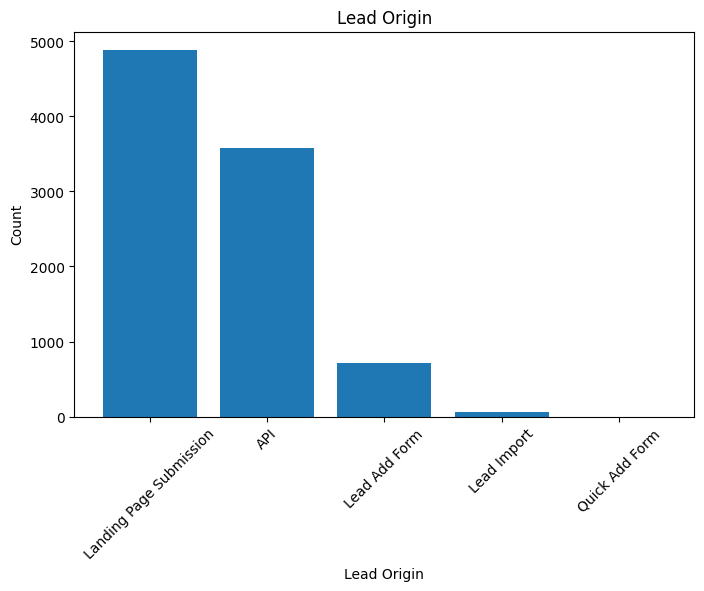

Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64


In [33]:
lead_origin = df["Lead Origin"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(lead_origin.index, lead_origin.values)
plt.title("Lead Origin")
plt.xlabel("Lead Origin")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
print(lead_origin)

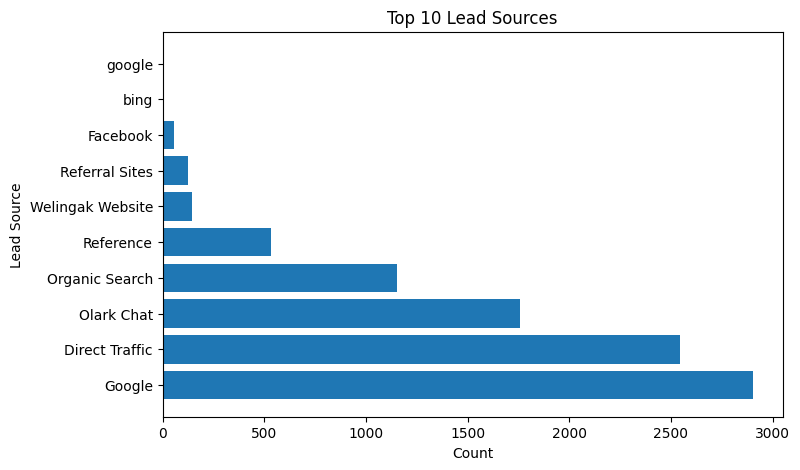

Lead Source
Google              2904
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
bing                   6
google                 5
Name: count, dtype: int64


In [34]:
lead_source = df["Lead Source"].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(lead_source.index, lead_source.values)
plt.title("Top 10 Lead Sources")
plt.xlabel("Count")
plt.ylabel("Lead Source")
plt.show()
print(lead_source)

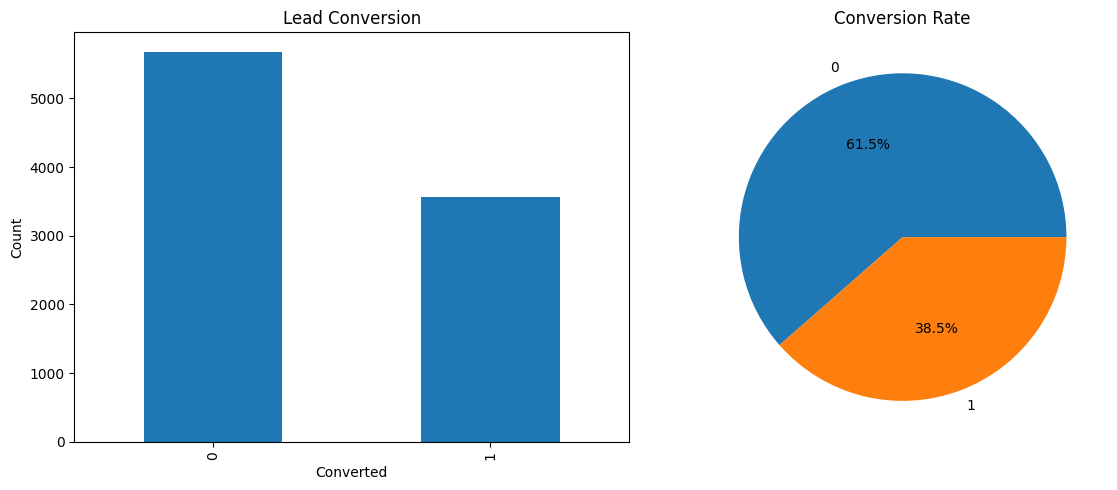

Conversion Rate: 38.54 %


In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

df["Converted"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Lead Conversion")
ax[0].set_xlabel("Converted")
ax[0].set_ylabel("Count")

df["Converted"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Conversion Rate")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()
print("Conversion Rate:", round(df["Converted"].mean()*100, 2), "%")

In [36]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop("Converted", errors="ignore")

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X = df_model.drop("Converted", axis=1)
y = df_model["Converted"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (9240, 176)
y Shape: (9240,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Train Conversion:", round(y_train.mean()*100, 2), "%")
print("Test Conversion:", round(y_test.mean()*100, 2), "%")

Train Shape: (6468, 176)
Test Shape: (2772, 176)
Train Conversion: 38.4 %
Test Conversion: 38.85 %


## Model Training

Now I will train different machine learning models and compare their performance. I am using hyperparameter tuning to find the best settings for each model.

In [38]:
print("Training models...")

models = {

    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "max_iter": [500, 1000]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [5, 10, 15],
            "min_samples_split": [2, 5]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    }

}

model_results = []
best_models = {}

print("Models are ready.")

Training models...
Models are ready.


## Model Training and Hyperparameter Tuning

Now I am training different machine learning models and comparing their performance. I will select the model with the best ROC-AUC score.

In [39]:
print("Training Logistic Regression...")

name = "Logistic Regression"

grid_search = GridSearchCV(
    models[name]["model"],
    {
        "C": models[name]["params"]["C"],
        "max_iter": [2000, 5000],
        "solver": ["liblinear"]
    },
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_models[name] = grid_search.best_estimator_

print("Training Completed")
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", round(grid_search.best_score_, 3))

Training Logistic Regression...
Training Completed
Best Parameters: {'C': 10, 'max_iter': 2000, 'solver': 'liblinear'}
Best ROC-AUC Score: 0.957


In [40]:
print("Training Decision Tree...")

name = "Decision Tree"

grid_search = GridSearchCV(
    models[name]["model"],
    models[name]["params"],
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_models[name] = grid_search.best_estimator_
print("Done")
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", round(grid_search.best_score_, 3))

Training Decision Tree...
Done
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}
Best ROC-AUC Score: 0.934


In [41]:
print("Training Random Forest...")

name = "Random Forest"

grid_search = GridSearchCV(
    models[name]["model"],
    models[name]["params"],
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_models[name] = grid_search.best_estimator_

print("Training Completed")
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", round(grid_search.best_score_, 3))

Training Random Forest...
Training Completed
Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best ROC-AUC Score: 0.962


In [42]:
print("Training XGBoost...")

name = "XGBoost"

grid_search = GridSearchCV(
    models[name]["model"],
    models[name]["params"],
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_models[name] = grid_search.best_estimator_

print("Training Completed")
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", round(grid_search.best_score_, 3))

Training XGBoost...
Training Completed
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best ROC-AUC Score: 0.968


In [43]:
print("Evaluating Models...")

for name, model in best_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    model_results.append({
        "Model": name,
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1 Score": round(f1 * 100, 2),
        "ROC AUC": round(roc_auc, 3)
    })

    print(f"{name} Completed")
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"ROC-AUC  : {roc_auc:.3f}\n")

print("All models evaluated successfully.")

Evaluating Models...
Logistic Regression Completed
Accuracy : 91.16%
ROC-AUC  : 0.966

Decision Tree Completed
Accuracy : 90.37%
ROC-AUC  : 0.950

Random Forest Completed
Accuracy : 92.21%
ROC-AUC  : 0.969

XGBoost Completed
Accuracy : 92.39%
ROC-AUC  : 0.976

All models evaluated successfully.


In [44]:
# Checking all the model results
results_df = pd.DataFrame(model_results)
print("Model Comparison")
print(results_df)
# Finding the best model
best_model_name = results_df.loc[results_df["ROC AUC"].idxmax(), "Model"]
best_model = best_models[best_model_name]

print("\nBest Model:", best_model_name)
print("ROC-AUC Score:", results_df["ROC AUC"].max())

Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression     91.16      89.47   87.56     88.50    0.966
1        Decision Tree     90.37      90.66   83.84     87.12    0.950
2        Random Forest     92.21      91.04   88.67     89.84    0.969
3              XGBoost     92.39      90.93   89.32     90.12    0.976

Best Model: XGBoost
ROC-AUC Score: 0.976


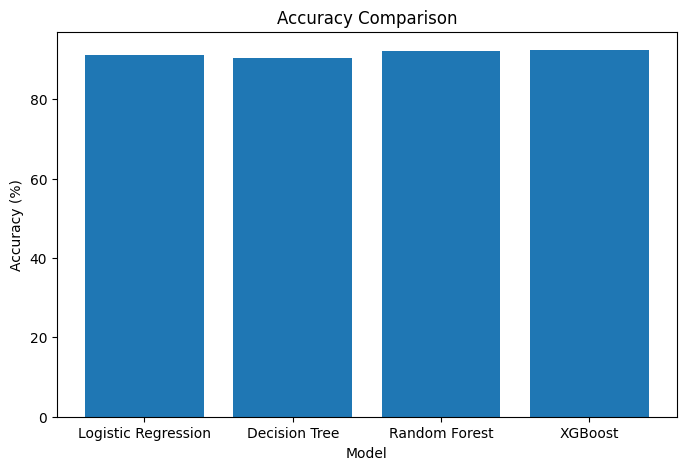

In [45]:
# Compareing all the models accuracy

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.show()

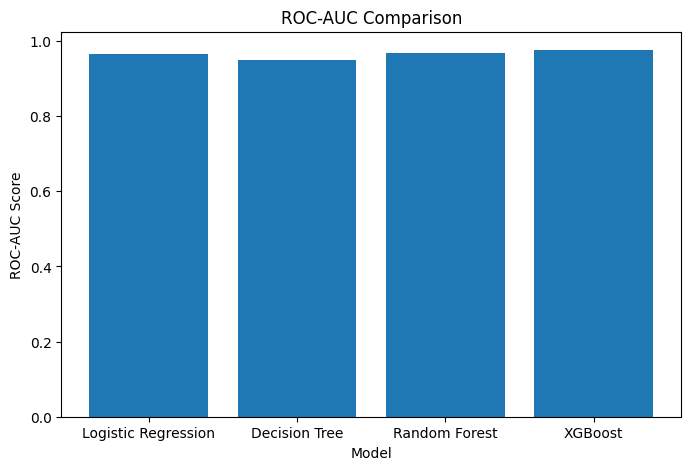

In [46]:
# Compare ROC-AUC score

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["ROC AUC"])

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")

plt.show()

## Model Evaluation

Now I am checking the performance of the best model using different evaluation metrics.

In [47]:
# Check the final model

print("Final Model Evaluation")

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Best Model:", best_model_name)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("ROC-AUC Score:", round(roc_auc, 3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)

# Classification report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Final Model Evaluation
Best Model: XGBoost
Accuracy: 92.39 %
ROC-AUC Score: 0.976

Confusion Matrix
[[1599   96]
 [ 115  962]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1695
           1       0.91      0.89      0.90      1077

    accuracy                           0.92      2772
   macro avg       0.92      0.92      0.92      2772
weighted avg       0.92      0.92      0.92      2772



In [48]:
# Generate lead scores

print("Generating Lead Scores...")

lead_scores = y_prob * 100

results_df = pd.DataFrame({
    "Lead Score": lead_scores,
    "Actual Converted": y_test.values,
    "Predicted Converted": y_pred
})

results_df = results_df.sort_values("Lead Score", ascending=False)

print("Total Leads:", len(results_df))
print("Score Range:", round(lead_scores.min(), 1), "-", round(lead_scores.max(), 1))

print("\nTop 10 Leads")
print(results_df.head(10))

Generating Lead Scores...
Total Leads: 2772
Score Range: 0.1 - 99.8

Top 10 Leads
      Lead Score  Actual Converted  Predicted Converted
2354   99.801956                 1                    1
1299   99.786903                 1                    1
752    99.776039                 1                    1
1859   99.776039                 1                    1
2174   99.743690                 1                    1
919    99.725113                 1                    1
1463   99.714508                 1                    1
1851   99.706467                 1                    1
133    99.701332                 1                    1
1475   99.693016                 1                    1


In [49]:
# Divide leads into categories

def categorize_lead(score):
    if score >= 70:
        return "Hot"
    elif score >= 40:
        return "Warm"
    else:
        return "Cold"

results_df["Category"] = results_df["Lead Score"].apply(categorize_lead)

category_stats = results_df.groupby("Category").agg({
    "Lead Score": ["count", "mean"],
    "Actual Converted": "mean"
}).round(2)

category_stats.columns = ["Lead Count", "Average Score", "Conversion Rate"]

print("Lead Categories")
print(category_stats)

print("\nHot Leads:", len(results_df[results_df["Category"] == "Hot"]))

Lead Categories
          Lead Count  Average Score  Conversion Rate
Category                                            
Cold            1646       6.550000             0.05
Hot              954      92.400002             0.94
Warm             172      54.950001             0.56

Hot Leads: 954


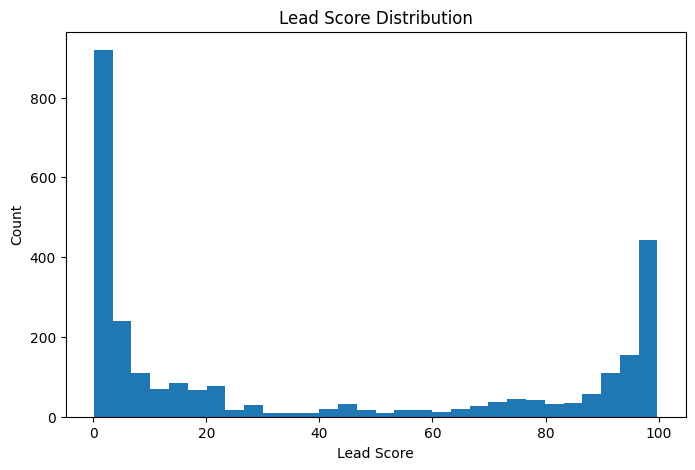

In [50]:
# Lead score distribution

plt.figure(figsize=(8,5))

plt.hist(lead_scores, bins=30)

plt.title("Lead Score Distribution")
plt.xlabel("Lead Score")
plt.ylabel("Count")

plt.show()

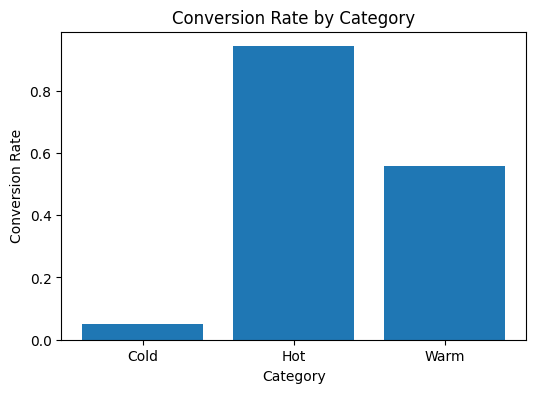

In [51]:
# Conversion rate for each category

category_conv = results_df.groupby("Category")["Actual Converted"].mean()

plt.figure(figsize=(6,4))

plt.bar(category_conv.index, category_conv.values)

plt.title("Conversion Rate by Category")
plt.xlabel("Category")
plt.ylabel("Conversion Rate")

plt.show()

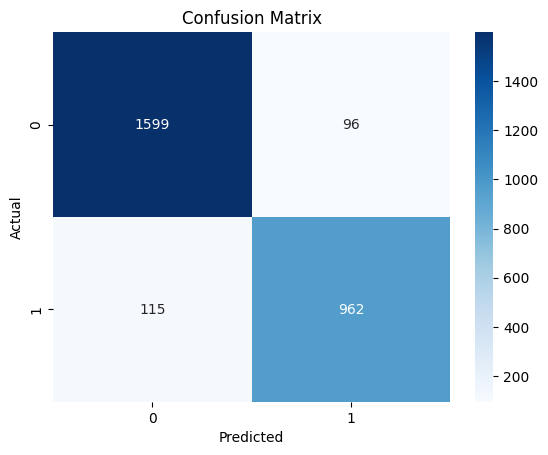

In [52]:
# Confusion matrix

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
# Final observations

current_conversion = y_test.mean()

hot_leads = results_df[results_df["Category"] == "Hot"]
hot_conversion = hot_leads["Actual Converted"].mean()

print("Final Results")
print("Best Model:", best_model_name)
print("Total Leads:", len(results_df))
print("Overall Conversion Rate:", round(current_conversion * 100, 2), "%")
print("Hot Leads:", len(hot_leads))
print("Hot Lead Conversion Rate:", round(hot_conversion * 100, 2), "%")

improvement = hot_conversion - current_conversion

print("Improvement:", round(improvement * 100, 2), "%")

print("\nSuggestions")
print("1. Contact Hot Leads first.")
print("2. Follow up with Warm Leads.")
print("3. Cold Leads can be given lower priority.")
print("4. Use the selected model for lead scoring.")

Final Results
Best Model: XGBoost
Total Leads: 2772
Overall Conversion Rate: 38.85 %
Hot Leads: 954
Hot Lead Conversion Rate: 94.23 %
Improvement: 55.38 %

Suggestions
1. Contact Hot Leads first.
2. Follow up with Warm Leads.
3. Cold Leads can be given lower priority.
4. Use the selected model for lead scoring.


## CEO Target Analysis

This model gives a lead score to every customer based on the chances of conversion. Higher lead scores mean a higher probability that the customer will become a paying customer.

- **Hot Leads (70 and above):** These leads have the highest chance of conversion and should be contacted first.
- **Warm Leads (40–69):** These leads have a moderate chance of conversion and need regular follow-up.
- **Cold Leads (Below 40):** These leads have a low chance of conversion and can be given lower priority.

By focusing on Hot Leads first, the sales team can use their time more effectively and improve the overall conversion rate.

After comparing Logistic Regression, Decision Tree, Random Forest, and XGBoost, **{best_model_name}** gave the best performance, so it was selected for lead scoring.

In [54]:
# Save the output files

results_df.to_csv("lead_scores.csv", index=False)

summary_df = pd.DataFrame({
    "Best Model": [best_model_name],
    "Total Leads": [len(results_df)],
    "Hot Leads": [len(results_df[results_df["Category"] == "Hot"])],
    "Accuracy": [round(accuracy * 100, 2)],
    "ROC AUC": [round(roc_auc, 3)]
})

summary_df.to_csv("model_summary.csv", index=False)

pd.DataFrame(model_results).to_csv("model_comparison_results.csv", index=False)

print("Lead scores saved.")
print("Model summary saved.")
print("Model comparison saved.")

print("\nFinal Results")
print("Best Model:", best_model_name)
print("Total Leads:", len(results_df))
print("Hot Leads:", len(results_df[results_df["Category"] == "Hot"]))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("ROC-AUC:", round(roc_auc, 3))

Lead scores saved.
Model summary saved.
Model comparison saved.

Final Results
Best Model: XGBoost
Total Leads: 2772
Hot Leads: 954
Accuracy: 92.39 %
ROC-AUC: 0.976


In [55]:
# Final project summary

print("Project Summary")

print("Best Model:", best_model_name)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("ROC-AUC:", round(roc_auc, 3))

print("Total Leads:", len(results_df))
print("Hot Leads:", len(results_df[results_df["Category"] == "Hot"]))

baseline = results_df["Actual Converted"].mean()
hot_rate = results_df[results_df["Category"] == "Hot"]["Actual Converted"].mean()

print("Overall Conversion Rate:", round(baseline * 100, 2), "%")
print("Hot Lead Conversion Rate:", round(hot_rate * 100, 2), "%")

print("\nFiles Created")
print("- lead_scores.csv")
print("- model_summary.csv")
print("- model_comparison_results.csv")

Project Summary
Best Model: XGBoost
Accuracy: 92.39 %
ROC-AUC: 0.976
Total Leads: 2772
Hot Leads: 954
Overall Conversion Rate: 38.85 %
Hot Lead Conversion Rate: 94.23 %

Files Created
- lead_scores.csv
- model_summary.csv
- model_comparison_results.csv


## Project Conclusion

In this project, I cleaned the lead scoring dataset and handled the missing values before training the models. I trained and compared four machine learning models using hyperparameter tuning.

After comparing all the models, **XGBoost** performed the best, so I selected it as the final model.

The selected model was used to generate lead scores between 0 and 100 and classify the leads into Hot, Warm, and Cold categories. This can help the sales team focus on leads that have a higher chance of conversion.

Overall, this project shows how machine learning can be used to identify high-potential leads and improve the lead scoring process.

In [56]:
# Save model for Streamlit

os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/xgboost_model.pkl")
joblib.dump(X_train.columns.tolist(), "model/features.pkl")

print("Model saved successfully.")

Model saved successfully.
